In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

import joblib

In [2]:
df = pd.read_csv("../data/train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
print("datatype:",df.dtypes)
print("name of columns:",df.columns)
print(df.shape)
df.describe()

datatype: PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object
name of columns: Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')
(891, 12)


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [4]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [5]:
df["Survived"].value_counts()
# Percentage of survival
df["Survived"].value_counts(normalize=True) * 100

Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64

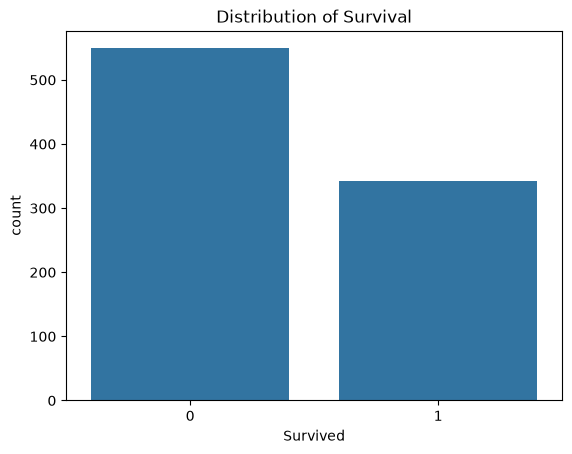

In [6]:
sns.countplot(x="Survived", data=df)
plt.title("Distribution of Survival")
plt.show()

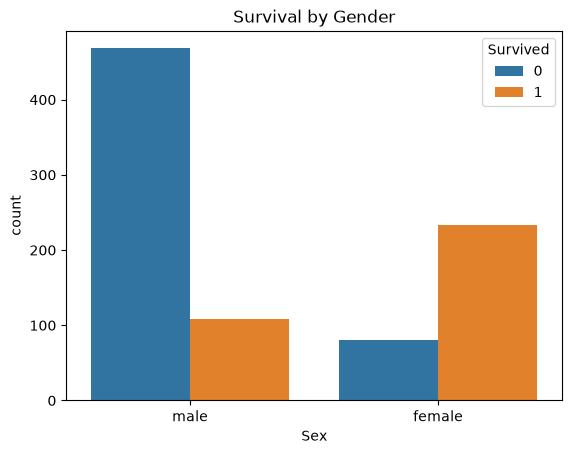

In [7]:
# Count males and females
df["Sex"].value_counts()

# Survival by gender
pd.crosstab(df["Sex"], df["Survived"])

# Percentage survival by gender
pd.crosstab(df["Sex"], df["Survived"], normalize="index") * 100

# Visualization
sns.countplot(x="Sex", hue="Survived", data=df)
plt.title("Survival by Gender")
plt.show()

 female survive slightly more than men therefore sex is an important factor in deciding the survival.

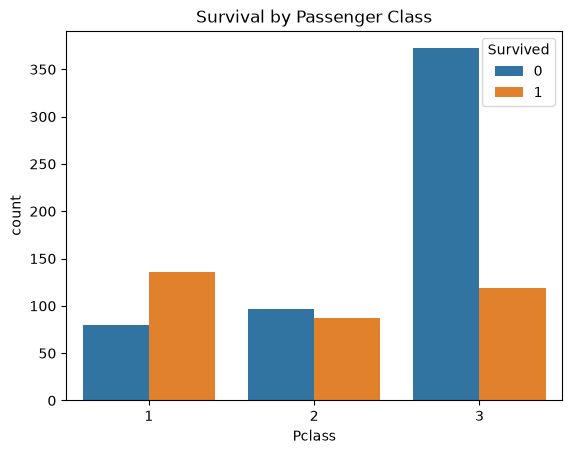

In [8]:
# Count passengers in each class
df["Pclass"].value_counts()
# Survival by passenger class
pd.crosstab(df["Pclass"], df["Survived"])

# Survival percentage by passenger class
pd.crosstab(df["Pclass"], df["Survived"], normalize="index") * 100

# Visualization
sns.countplot(x="Pclass", hue="Survived", data=df)
plt.title("Survival by Passenger Class")
plt.show()


survival rate according to class increase from third to first

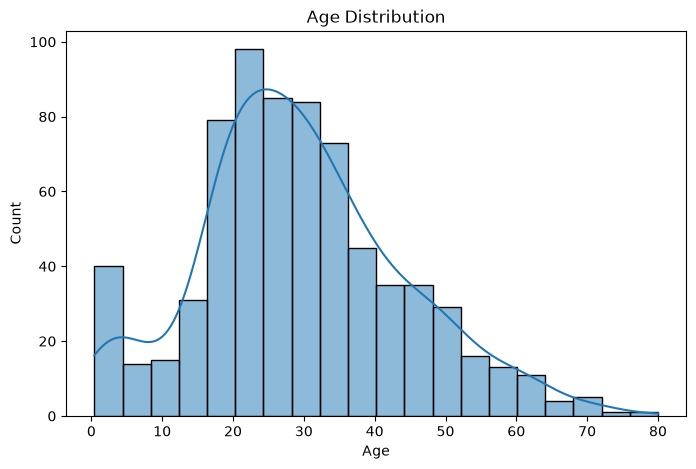

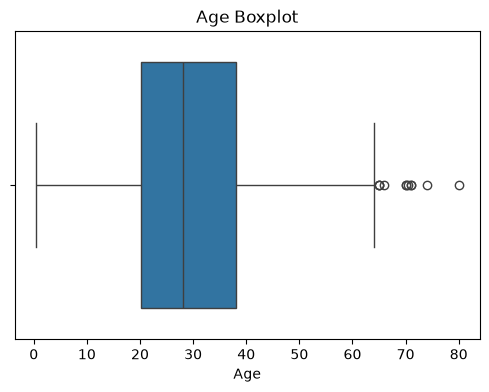

In [9]:
# Basic statistics
df["Age"].describe()

# Distribution
plt.figure(figsize=(8,5))
sns.histplot(df["Age"], kde=True)
plt.title("Age Distribution")
plt.show()

# Box plot
plt.figure(figsize=(6,4))
sns.boxplot(x=df["Age"])
plt.title("Age Boxplot")
plt.show()

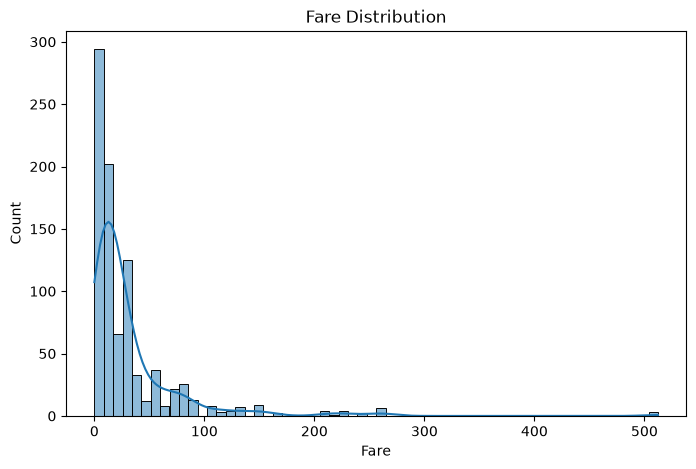

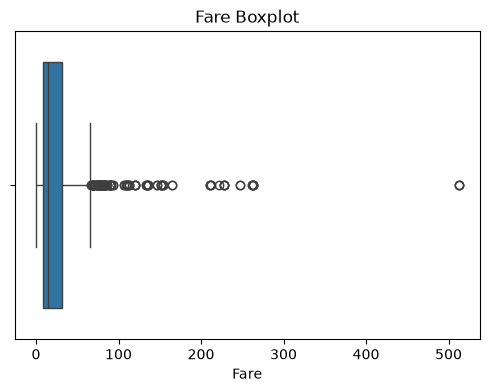

In [10]:
df["Fare"].describe()

plt.figure(figsize=(8,5))
sns.histplot(df["Fare"], kde=True)
plt.title("Fare Distribution")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x=df["Fare"])
plt.title("Fare Boxplot")
plt.show()

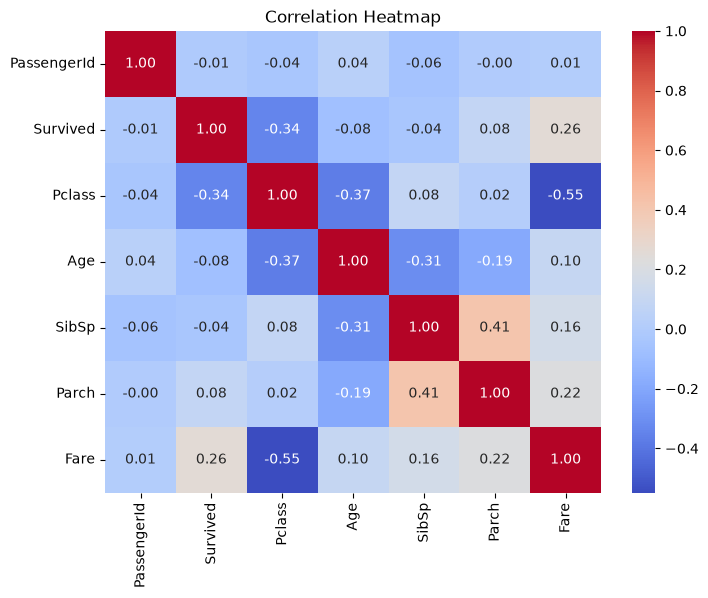

In [11]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

In [12]:

df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
df = df.drop(columns=["PassengerId", "Name", "Ticket"])
df.drop(columns=["Cabin"], inplace=True)
df.head()


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [13]:
df.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

In [14]:
le=LabelEncoder()
df["Sex"] = le.fit_transform(df["Sex"])
df = pd.get_dummies(df, columns=["Embarked"], drop_first=True)
df.head()


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,1,22.0,1,0,7.2500,False,True
1,1,1,0,38.0,1,0,71.2833,False,False
2,1,3,0,26.0,0,0,7.9250,False,True
3,1,1,0,35.0,1,0,53.1000,False,True
4,0,3,1,35.0,0,0,8.0500,False,True


In [15]:
y=df['Survived']
X=df.drop(columns=['Survived'])
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,
    random_state=42
)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(712, 8)
(179, 8)
(712,)
(179,)


In [16]:
scaler = StandardScaler()

# Learn mean and std from training data
X_train = scaler.fit_transform(X_train)

# Apply the same transformation to test data
X_test = scaler.transform(X_test)

In [17]:
model = LogisticRegression(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8100558659217877


[[90 15]
 [19 55]]
              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



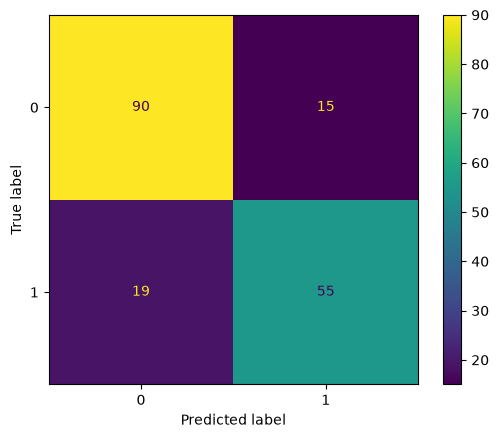

In [18]:
cm = confusion_matrix(y_test, y_pred)
print(cm)
ConfusionMatrixDisplay(confusion_matrix=cm).plot()
print(classification_report(y_test, y_pred))

In [19]:
# Original features (before scaling)
X = df.drop(columns=["Survived"])
y = df["Survived"]

# Train-Test Split (Unscaled)
X_train_dt, X_test_dt, y_train_dt, y_test_dt = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [20]:
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_dt, y_train_dt)
y_pred_dt = dt_model.predict(X_test_dt)
from sklearn.metrics import accuracy_score
accuracy_dt = accuracy_score(y_test_dt, y_pred_dt)
print("Decision Tree Accuracy:", accuracy_dt)

Decision Tree Accuracy: 0.7877094972067039


In [21]:
accuracy_dt = accuracy_score(y_test_dt, y_pred_dt)
print("Decision Tree Accuracy:", accuracy_dt)
train_pred = dt_model.predict(X_train_dt)

train_accuracy = accuracy_score(y_train_dt, train_pred)

print("Training Accuracy:", train_accuracy)

Decision Tree Accuracy: 0.7877094972067039
Training Accuracy: 0.9789325842696629


In [22]:
dt_model2 = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)
dt_model2.fit(X_train_dt, y_train_dt)
y_pred2 = dt_model2.predict(X_test_dt)
print("Test Accuracy:", accuracy_score(y_test_dt, y_pred2))
train_pred2 = dt_model2.predict(X_train_dt)
print(
    "Training Accuracy:",
    accuracy_score(y_train_dt, train_pred2)
)

Test Accuracy: 0.7988826815642458
Training Accuracy: 0.8342696629213483


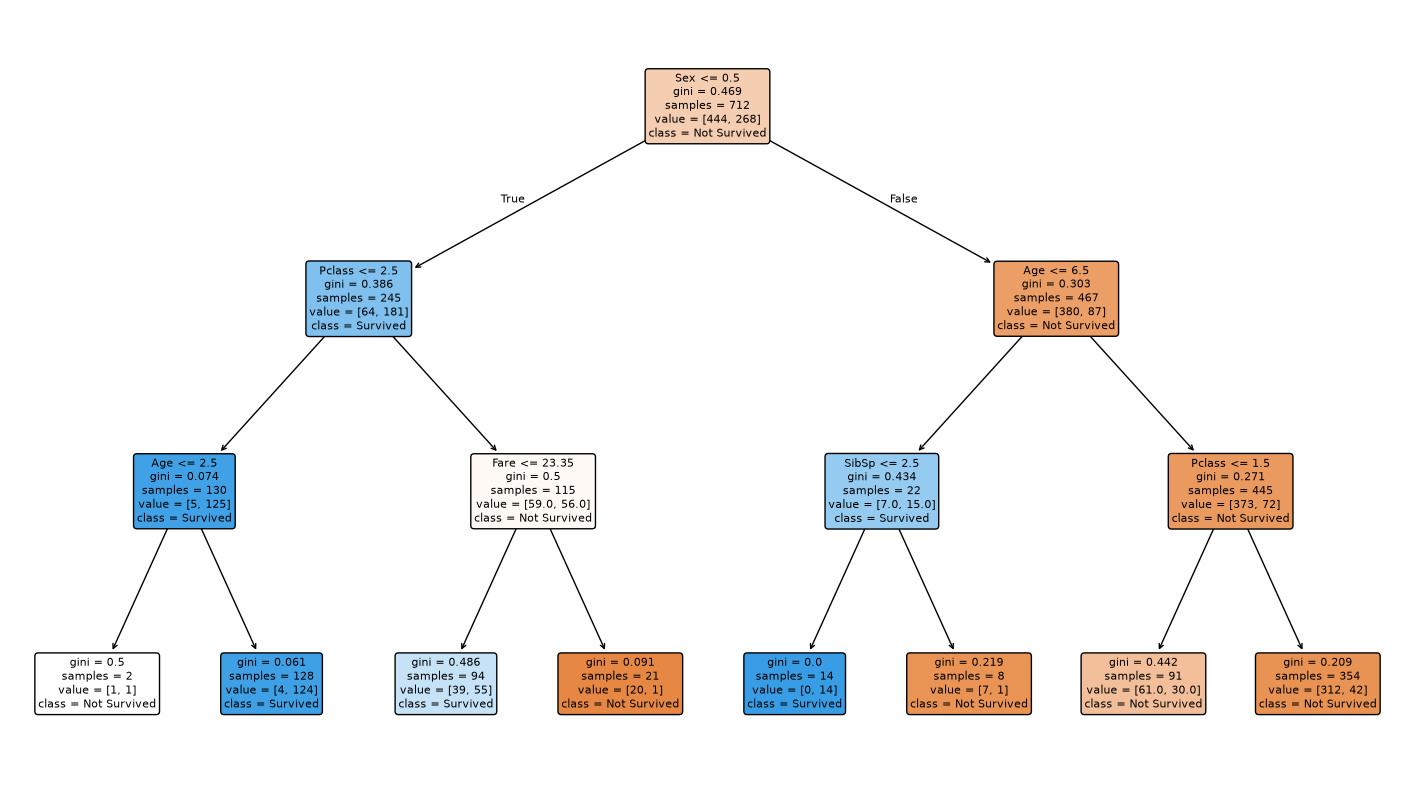

In [23]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(18,10))

plot_tree(
    dt_model2,
    feature_names=X.columns,
    class_names=["Not Survived", "Survived"],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.show()